In [1]:
%matplotlib inline
import os
import torch
import torchvision
from d2l import torch as d2l

In [2]:
#@save
d2l.DATA_HUB['voc2012'] = (d2l.DATA_URL + 'VOCtrainval_11-May-2012.tar',
                           '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')

voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')

In [3]:
#@save
def read_voc_images(voc_dir, is_train=True):
    """读取所有VOC图像并标注"""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
#     VOC 数据集有一个文本文件列表，里面每行一个图片 id（不带后缀）。
# 当 is_train=True 时用：
# voc_dir/ImageSets/Segmentation/train.txt
# 否则用：
# voc_dir/ImageSets/Segmentation/val.txt
# 这些 txt 文件告诉你“训练集/验证集包含哪些样本”。
    
    mode = torchvision.io.image.ImageReadMode.RGB
#     mode 用来指定 read_image 读图的输出格式。
# 这里设成 RGB 表示读取成 3 通道（C=3）。
# ⚠️ 注意：语义分割的 label PNG 通常是“索引图/调色板图（palette）”，严格来说更合适用单通道（比如 GRAY 或保持原格式），但 d2l 的 VOC 分割实现里常把它读成 RGB，是为了后续用一个 colormap 去映射类别颜色（或者把 RGB 颜色再映射回类别 id）。
    with open(txt_fname, 'r') as f:
        images = f.read().split()
#         打开 txt 文件，读取全部内容。
# split() 按空白分割成列表。
# images 里每个元素是一个字符串 id，例如：'2007_000033'
    
    features, labels = [], []
#     features：存原图（JPEGImages）
# labels：存分割标注（SegmentationClass）
# enumerate 给你 (i, fname)，其中 i 是序号，这里其实没用到（可以不用 enumerate）。
    
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
#         拼路径：voc_dir/JPEGImages/<id>.jpg
# torchvision.io.read_image 读成 torch.Tensor，形状通常是：
# (3, H, W)，dtype 通常 uint8，值域 0~255
# 加入 features 列表。
        
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
#         拼路径：voc_dir/SegmentationClass/<id>.png
# 这是语义分割的像素级标注（每个像素属于哪个类别）。
# 用 mode=RGB 读取后，一般会得到：
# (3, H, W) 的张量（3通道颜色），dtype uint8
    
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

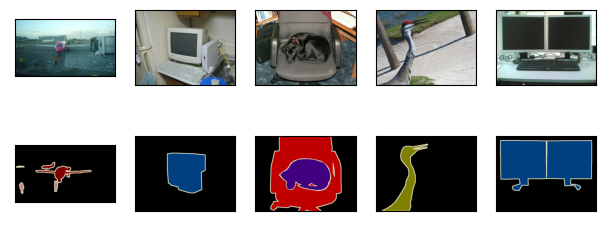

In [5]:
n = 5
imgs = train_features[0:n] + train_labels[0:n]
imgs = [img.permute(1,2,0) for img in imgs]
d2l.show_images(imgs, 2, n);
# 这段代码是在 把训练集里的前 5 张原图 + 前 5 张分割标签图（mask）拼在一起显示出来，方便你直观看到 VOC 语义分割数据的“图片-标注”是否对齐、读没读对。

In [6]:
#@save
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

#@save
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

In [9]:
#@save
def voc_colormap2label():
    """构建从RGB到VOC类别索引的映射"""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
#         idx=(R×256+G)×256+B=R×256^2 +G×256+B
# 这样每种 RGB 颜色都会对应一个唯一的 idx（范围 0 ~ 256^3-1）。
# 然后把这个位置赋值为类别 id i。
    return colormap2label

#@save
def voc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]
#     colormap 输入通常是你读入的 VOC 标签图（mask），形状是 (C,H,W)。
# 因为 torchvision.io.read_image 返回的是 CHW
# permute(1,2,0) 把它变成 (H,W,C)，方便按像素取 RGB。
# .numpy() 转成 numpy 数组。
# .astype('int32') 转成 int32，避免后面乘法溢出/类型问题。
# 最终 colormap 形状是 (H, W, 3)，每个位置是一个 RGB。

In [10]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]
# 把 第 0 张 VOC 的分割标注图（RGB mask） 转成 类别索引矩阵 y

# 从 y 里截取一小块像素区域来看里面的类别 id，同时查看 VOC_CLASSES[1] 这个类别名称

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

In [11]:
#预处理数据

In [13]:
#@save
def voc_rand_crop(feature, label, height, width):
    """随机裁剪特征和标签图像"""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    # RandomCrop.get_params(img, output_size) 会随机生成一个裁剪参数 rect。
    feature = torchvision.transforms.functional.crop(feature, *rect)
#     functional.crop(img, top, left, height, width) 对图像执行裁剪。
# *rect 是解包，把 rect=(i,j,h,w) 变成参数列表传进去。
# 裁剪后：
# feature 变成 (C, height, width)（如果输入是 CHW）
    
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

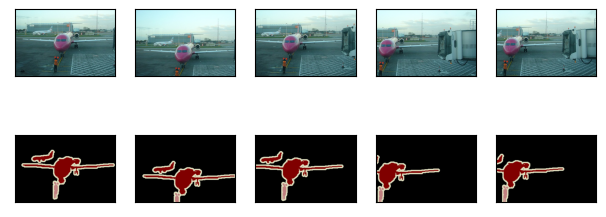

In [14]:
imgs = []
for _ in range(n):
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)

imgs = [img.permute(1, 2, 0) for img in imgs]
# torchvision.io.read_image 得到的是 (C,H,W)。
# d2l.show_images / matplotlib 更习惯 (H,W,C)。
# permute(1,2,0) 把维度从 CHW 变成 HWC。
# 所以每个裁剪块从：
# (3, 200, 300) 变成 (200, 300, 3)。

d2l.show_images(imgs[::2] + imgs[1::2], 2, n);